# NFL player-trajectory forecasting: reproduced neural systems and ensemble frontier

**Evidence snapshot: September 23, 2026 UTC.** Alvaro Mendizabal.

This notebook is the employer-facing evidence layer for the current neural research line. It reconstructs aggregate arithmetic, preserves negative findings, and separates local OOF evidence from private leaderboard measurements. It contains no raw tracking, player identities, credentials, or fitted weights.

## Problem and current capability

Forecast selected players’ future x/y positions after the pass from observed tracking, player roles, organizer-supplied landing location, and forecast horizon. The current system combines source-faithful temporal convolutions, cross-player attention, EMA inference, and controlled diversity mechanisms. The strongest measured deployment is a fixed equal seven-model ensemble: five game-fold bases plus one independent-seed model and one protected context-dropout model.

## Validation contract

The base family uses five game-grouped folds. Every OOF row comes only from a model that excluded that game. Coordinate RMSE pools squared coordinate errors before the final square root. Checkpoint selection and repeated research inspection mean OOF is model-selection evidence rather than an untouched final test. Private Kaggle scores are reported separately and are the authoritative measurement of deployed ensembles.

In [1]:
import json, math, io, base64
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from IPython.display import display
E=json.loads(Path('research/evidence/model_reproduction.json').read_text())
def show(fig, static, name, height=480):
    fig.update_layout(width=940,height=height,margin=dict(l=90,r=40,t=80,b=80),font=dict(size=14))
    static.set_size_inches(9.4,height/100);static.tight_layout()
    buf=io.BytesIO();static.savefig(buf,format='png',dpi=120)
    Path('research/figures').mkdir(exist_ok=True)
    Path('research/figures/'+name+'.png').write_bytes(buf.getvalue())
    display({'application/vnd.plotly.v1+json':json.loads(fig.to_json()),'image/png':base64.b64encode(buf.getvalue()).decode()},raw=True)
    plt.close(static)
n=sum(f['rows'] for f in E['base_folds'])
r=math.sqrt(sum(f['rows']*f['rmse']**2 for f in E['base_folds'])/n)
assert n==561607 and abs(r-E['base_oof_rmse'])<1e-12
K=E['kaggle_private']
print(f'Base OOF: {r:.9f} coordinate RMSE across {n:,} excluded-game rows.')
print(f"Private score progression: {K['five_base_submission']['private_rmse']:.5f} -> {K['seven_model_submission']['private_rmse']:.5f}; final first-place private score {K['final_first_place_private_rmse']:.5f}.")
print('Late post-competition submissions: performance measurements only; no official rank claimed.')


Base OOF: 0.468143852 coordinate RMSE across 561,607 excluded-game rows.
Private score progression: 0.46615 -> 0.46547; final first-place private score 0.46340.
Late post-competition submissions: performance measurements only; no official rank claimed.


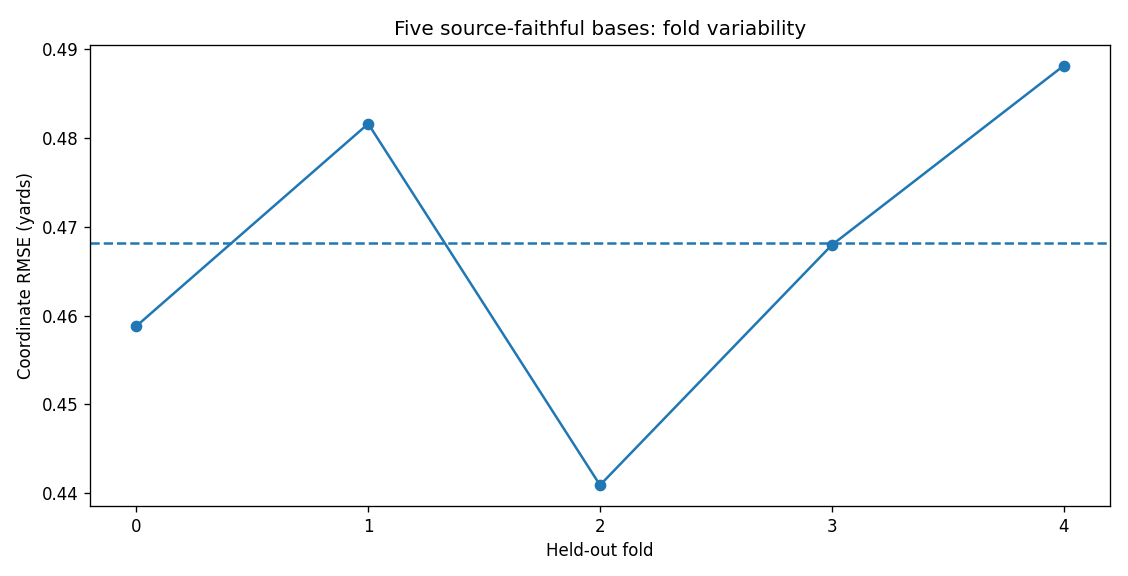

In [2]:
f=E['base_folds']; x=[str(v['fold']) for v in f]; y=[v['rmse'] for v in f]
fig=go.Figure(go.Scatter(x=x,y=y,mode='markers+lines',name='Excluded-game base',text=[f"{v['rows']:,} rows" for v in f]))
fig.update_layout(title='Five source-faithful bases: excluded-game fold variability',xaxis_title='Held-out fold',yaxis_title='Coordinate RMSE (yards; lower is better)')
fig.add_hline(y=E['base_oof_rmse'],line_dash='dash',annotation_text='Pooled OOF')
static,ax=plt.subplots();ax.plot(x,y,marker='o');ax.axhline(E['base_oof_rmse'],linestyle='--');ax.set(xlabel='Held-out fold',ylabel='Coordinate RMSE (yards)',title='Five source-faithful bases: fold variability')
show(fig,static,'winner_folds')


Fold variability is material. The pooled score is row-weighted through squared error, not an unweighted average of the five fold RMSEs.

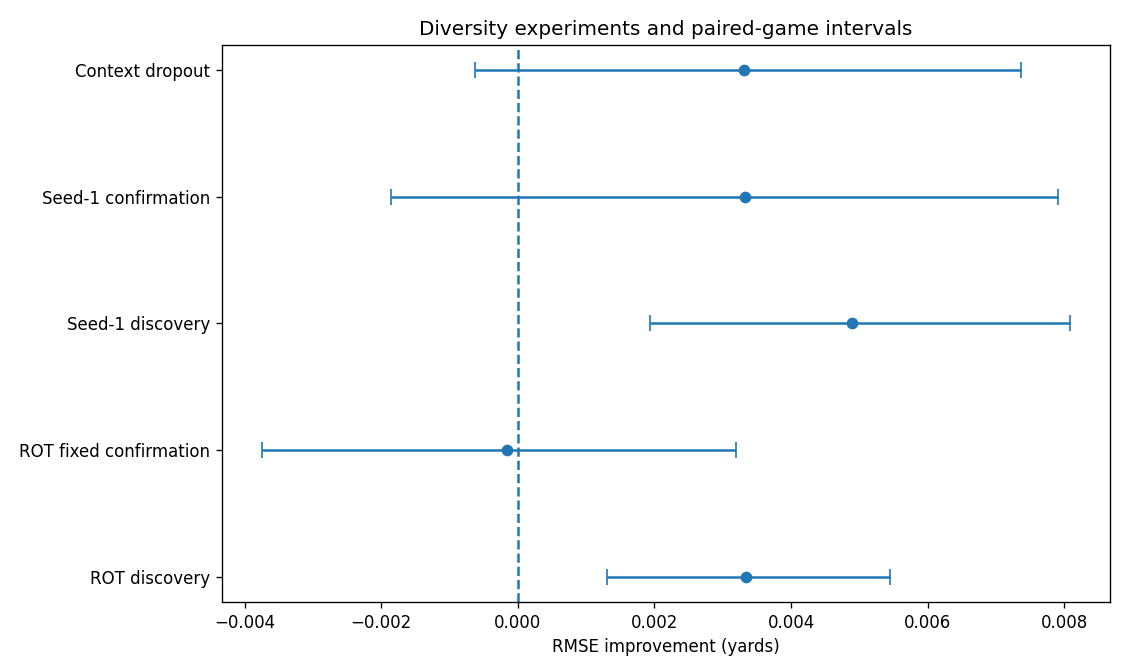

In [3]:
T=E['experiments']; labels=[t['name'] for t in T]; gains=[t['gain'] for t in T]
low=[t['gain']-t['interval95'][0] for t in T]; high=[t['interval95'][1]-t['gain'] for t in T]
fig=go.Figure(go.Scatter(x=gains,y=labels,mode='markers',error_x=dict(type='data',array=high,arrayminus=low,symmetric=False),text=[t['decision'] for t in T],hovertemplate='%{y}<br>gain=%{x:.6f}<br>%{text}<extra></extra>'))
fig.update_layout(title='Diversity experiments: point gains versus paired-game uncertainty',xaxis_title='Base RMSE minus fixed blend RMSE (positive is better)',yaxis_title='Experiment')
fig.add_vline(x=0,line_dash='dash')
static,ax=plt.subplots();ax.errorbar(gains,labels,xerr=[low,high],fmt='o',capsize=5);ax.axvline(0,linestyle='--');ax.set(xlabel='RMSE improvement (yards)',title='Diversity experiments and paired-game intervals')
show(fig,static,'winner_diversity',560)


Positive point movement is not enough for automatic promotion. Seed diversity passed Fold-0 discovery but its fixed Fold-1 interval crossed zero. Context dropout improved the Fold-0 fixed blend but its interval also crossed zero. Those models were retained as complementary ensemble members rather than advertised as independently validated upgrades.

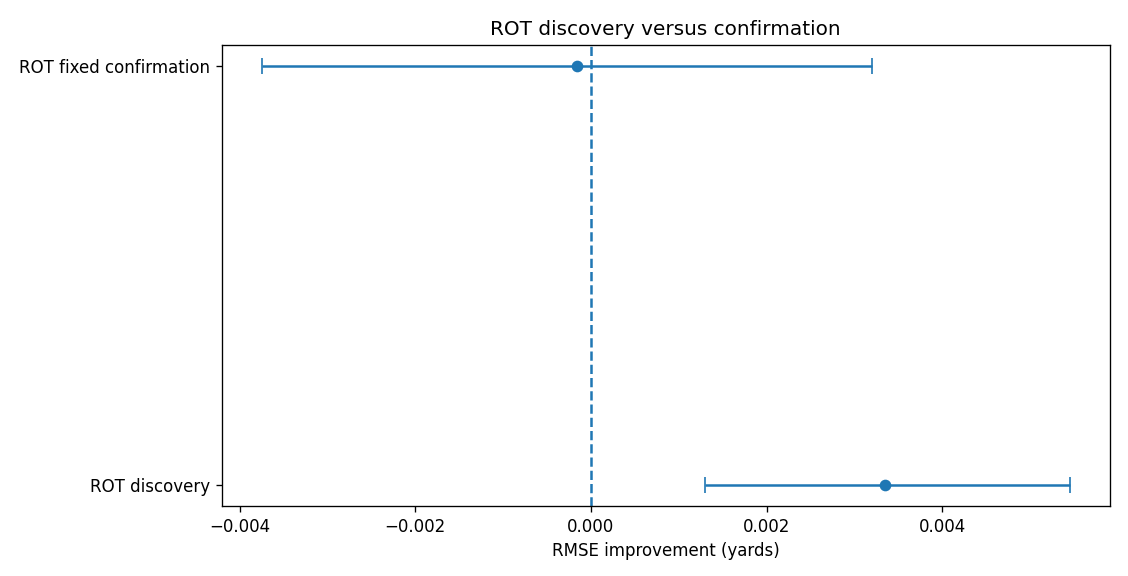

In [4]:
T=[t for t in E['experiments'] if t['family']=='geometry']; labels=[t['name'] for t in T]; gains=[t['gain'] for t in T]
low=[t['gain']-t['interval95'][0] for t in T];high=[t['interval95'][1]-t['gain'] for t in T]
fig=go.Figure(go.Scatter(x=gains,y=labels,mode='markers',error_x=dict(type='data',array=high,arrayminus=low,symmetric=False)))
fig.update_layout(title='ROT: discovery did not reproduce under the fixed confirmation',xaxis_title='RMSE improvement (yards)',yaxis_title='Experiment');fig.add_vline(x=0,line_dash='dash')
static,ax=plt.subplots();ax.errorbar(gains,labels,xerr=[low,high],fmt='o',capsize=5);ax.axvline(0,linestyle='--');ax.set(xlabel='RMSE improvement (yards)',title='ROT discovery versus confirmation')
show(fig,static,'winner_confirmation')


ROT geometry is the clearest replication example: the Fold-1 discovery passed its gate, while the fixed Fold-2 confirmation did not. The failure is retained rather than reweighted away.

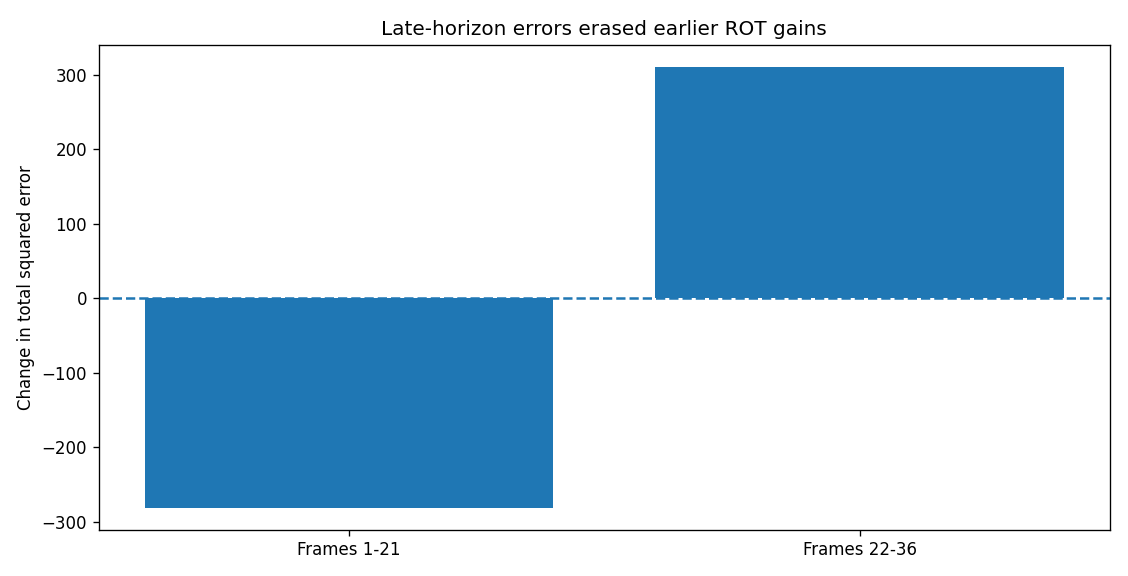

In [5]:
s=E['horizon_segments'];labels=[v['segment'] for v in s];delta=[v['delta_sse'] for v in s]
fig=go.Figure(go.Bar(x=labels,y=delta,text=[f"{v['rows']:,} rows" for v in s]))
fig.update_layout(title='Fold-2 ROT error analysis: late horizons erased earlier gains',xaxis_title='Forecast segment',yaxis_title='Blend minus base total squared error')
static,ax=plt.subplots();ax.bar(labels,delta);ax.axhline(0,linestyle='--');ax.set(ylabel='Change in total squared error',title='Late-horizon errors erased earlier ROT gains')
show(fig,static,'winner_horizon')


The post-hoc horizon split explains part of the ROT failure but is not used to retune the confirmation. The small late-horizon population contributed enough additional squared error to reverse earlier gains.

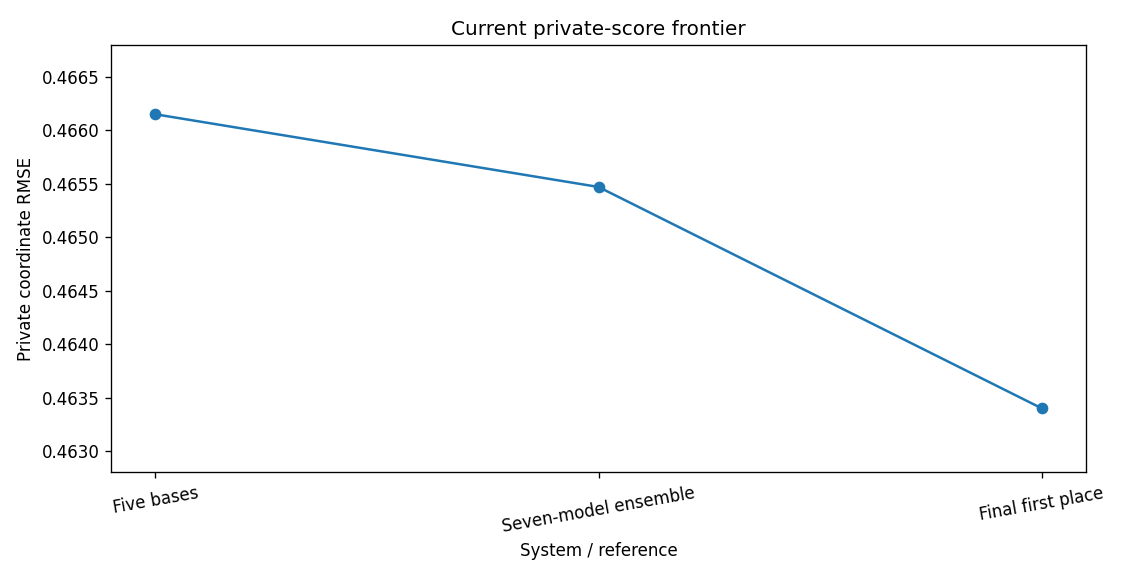

In [6]:
K=E['kaggle_private']; labels=['Five bases','Seven-model ensemble','Final first place'];vals=[K['five_base_submission']['private_rmse'],K['seven_model_submission']['private_rmse'],K['final_first_place_private_rmse']]
fig=go.Figure(go.Scatter(x=labels,y=vals,mode='markers+lines+text',text=[f'{v:.5f}' for v in vals],textposition='top center'))
fig.update_layout(title='Current private-score frontier: ensemble diversity narrowed the gap',xaxis_title='Measured system / reference',yaxis_title='Private coordinate RMSE (yards; lower is better)')
fig.update_yaxes(range=[0.4628,0.4668])
static,ax=plt.subplots();ax.plot(labels,vals,marker='o');ax.set(xlabel='System / reference',ylabel='Private coordinate RMSE',title='Current private-score frontier');ax.set_ylim(0.4628,0.4668);ax.tick_params(axis='x',rotation=10)
show(fig,static,'winner_private_progress')


## Deployment result

The five-base candidate scored **0.46615** private RMSE. The predeclared equal seven-model ensemble scored **0.46547**, an improvement of **0.00068**. The official final first-place private score is **0.46340**, so the remaining gap is **0.00207**. These are late post-competition submissions used as comparable performance measurements; no official rank is claimed. The local seven-model proxy improved by 0.003556053, larger than the leaderboard gain, so local screening was directionally useful but optimistic.

## Leading-solution reproduction boundary

The table below is intentionally explicit about what has and has not been recreated. “Adapted” means independently implemented and tested inside this project, not copied weights or hidden predictions.

In [7]:
rows=E['leading_solution_reproduction']
for r in rows:
    print(f"{r['status']:<34} | {r['capability']} — {r['evidence']}")
assert E['next_experiment']['status']=='prepared_not_executed'


Recreated and validated            | Source-faithful temporal + cross-player base architecture — five excluded-game folds; 561,607 OOF rows
Adapted and evaluated              | Independent-seed diversity — strong Fold0 point gain; Fold1 uncertainty confirmation failed
Adapted and evaluated              | Context-player dropout — Fold0 point gain; uncertainty gate failed; retained as complementary model
Recreated and validated on Kaggle  | Equal-weight heterogeneous ensemble — private RMSE 0.46615 -> 0.46547
Prepared; not yet executed         | Alternate grouped CV split family — next leakage-safe full-OOF diversity experiment
Partially represented              | Large multi-CV / feature-diverse ensemble — 7 models deployed versus substantially larger public leading ensembles
Not yet implemented                | Pretraining + multi-auxiliary transformer system — structural frontier if split diversity is insufficient


## Next research question

The next prepared experiment is a complete second game-grouped cross-validation split family. That tests a structurally new diversity source used by large leading ensembles. It is **not yet executed**, so this snapshot claims no alternate-CV metric. If split diversity is insufficient, the next architectural gap is the broader pretraining / multi-auxiliary transformer family rather than another ordinary seed.

AWS remains the private experimental workspace for raw data, weights, and checkpoint archives. GitHub is the curated evidence and engineering surface; the two are intentionally not mirrors.

In [8]:
K=E['kaggle_private']
assert K['seven_model_submission']['private_rmse']==0.46547
assert K['seven_model_submission']['private_rmse']>K['final_first_place_private_rmse']
assert E['frontier_equal7']['status']=='SCORED'
print('REVIEW_COMPLETE: five persisted inline figures; current private score and reproduction boundary verified.')

REVIEW_COMPLETE: five persisted inline figures; current private score and reproduction boundary verified.
